RideWise London
## Customer Segmentation & Retention Strategy

### Purpose

- Although the churn prediction models demonstrated limited predictive performance, customer segmentation remains valuable - for understanding rider behaviour and prioritising business interventions.

- Rather than predicting which individual rider will churn, this notebook groups riders according to their historical - - - behaviour and identifies appropriate retention strategies for each segment.

- Objectives:

- Explore the distribution of rider segments.
- Compare behavioural characteristics across segments.
- Quantify churn rates within each segment.
- Recommend targeted business actions.

### STEP 1 -  Import Relevant Libraries

In [23]:
# Step 1a — Import Libraries


import os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

warnings.filterwarnings("ignore")
%matplotlib inline
sns.set_theme(style="whitegrid", font_scale=1.2)


# import our algorithm libraries 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score



# Load Data
DATA_PROCESSED = os.path.join(
    "..",
    "data",
    "processed"
)

features = pd.read_csv(
    os.path.join(
        DATA_PROCESSED,
        "ridewise_features.csv"
    )
)

segments = pd.read_csv(
    os.path.join(
        DATA_PROCESSED,
        "segment_assignment.csv"
    )
)

In [24]:
# step 1b - Merge them.

segment_df = (
    features.merge(
        segments,
        on="user_id",
        how="left"
    )
)

segment_df.head()

,user_id,account_age_days,age,city,loyalty_status,avg_rating_given,was_referred,frequency,monetary_total,average_fare,...,peak_trip_ratio,weekend_trip_ratio,rainy_trip_ratio,preferred_payment,avg_driver_rating,avg_driver_acceptance_rate,preferred_vehicle,churned,cluster,segment
0,R00000,33,35,Nairobi,Bronze,5.0,1,24,349.74,14.572500,...,0.208333,0.166667,0.166667,Mobile Money,4.241667,0.699978,SUV,0,1,Dormant
1,R00001,170,35,Nairobi,Bronze,4.7,0,11,138.24,12.567273,...,0.181818,0.181818,0.000000,Card,4.145455,0.718857,Sedan,0,2,At-Risk
2,R00002,172,47,Lagos,Bronze,4.2,0,20,328.09,16.404500,...,0.450000,0.100000,0.300000,Card,4.110000,0.612854,Sedan,0,0,Champions
3,R00004,190,41,Lagos,Silver,3.9,1,14,236.95,16.925000,...,0.285714,0.500000,0.214286,Mobile Money,4.214286,0.758234,Sedan,0,0,Champions
4,R00005,597,40,Lagos,Bronze,5.0,0,17,249.76,14.691765,...,0.411765,0.117647,0.058824,Mobile Money,4.023529,0.677242,Sedan,0,2,At-Risk


### STEP 2 - Select Clustering Features

- K-Means uses numerical variables that describe rider behaviour.

- Features were selected to capture:

- Recency
- Frequency
- Monetary value
- Engagement
- Customer longevity



In [25]:
# step 2a - select clustering features
cluster_features = [

    "recency_days",

    "frequency",

    "monetary_total",

    "trip_frequency_monthly",

    "customer_lifetime_value",

    "trips_last_30_days",

    "avg_days_between_trips",

    "avg_trip_duration",

    "avg_tip_rate",

    "account_age_months"

]



X_cluster = segment_df[cluster_features]

X_cluster.head(10)

,recency_days,frequency,monetary_total,trip_frequency_monthly,customer_lifetime_value,trips_last_30_days,avg_days_between_trips,avg_trip_duration,avg_tip_rate,account_age_months
0,8,24,349.74,22.138182,10.598182,2.0,12.217391,31.333333,0.012193,1.084100
1,45,11,138.24,1.969647,0.813176,0.0,24.200000,30.181818,0.000823,5.584757
2,11,20,328.09,3.539535,1.907500,1.0,12.105263,32.400000,0.021981,5.650460
3,3,14,236.95,2.242947,1.247105,3.0,20.769231,36.928571,0.066116,6.241787
4,5,17,249.76,0.866801,0.418358,2.0,17.250000,30.411765,0.010792,19.612352
5,7,14,199.01,0.762361,0.356011,2.0,22.384615,31.500000,0.099523,18.363995
6,21,16,322.83,0.743573,0.492870,2.0,17.266667,39.250000,0.054258,21.517740
7,20,14,253.57,0.703234,0.418432,1.0,21.076923,33.928571,0.020440,19.908016
8,8,21,302.36,2.116689,1.001192,3.0,13.200000,31.904762,0.030942,9.921156
9,28,19,265.74,1.187598,0.545667,1.0,14.166667,36.315789,0.049051,15.998686


In [26]:
# step 2b - Standardize Features

# K-Means is distance-based.

# Features with larger numerical ranges can dominate the clustering process.

# Standardization ensures that every feature contributes equally.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_cluster)

print(X_scaled.shape)

(9204, 10)


### STEP 3 - Elbow Method

- The Elbow Method evaluates the within-cluster sum of squares (WCSS).

- As the number of clusters increases, WCSS decreases.

- The optimal number of clusters is typically where the improvement begins to level off, forming an "elbow."


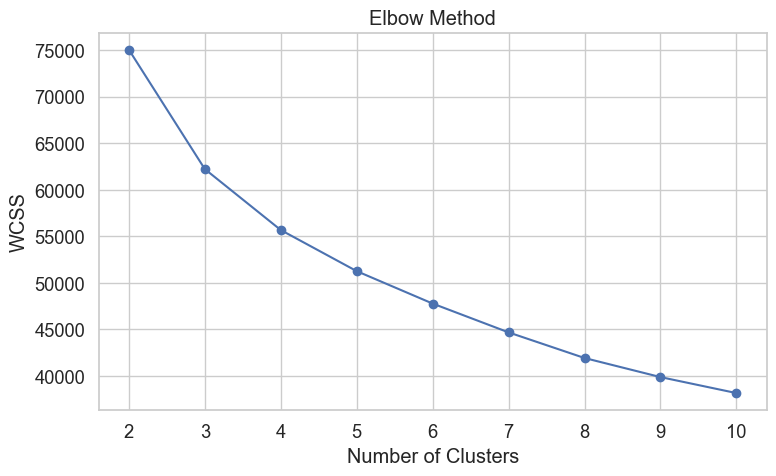

In [27]:
 
from sklearn.cluster import KMeans

# step 3a - Determine the Number of Clusters

wcss = []

cluster_range = range(2, 11)

for k in cluster_range:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

# step 3b - Plot it.

fig, ax = plt.subplots(figsize=(8,5))

ax.plot(
    cluster_range,
    wcss,
    marker="o"
)

ax.set_xlabel("Number of Clusters")

ax.set_ylabel("WCSS")

ax.set_title("Elbow Method")

plt.tight_layout()

plt.show()

### Insight

- The Elbow Method identifies the point where adding additional clusters provides only marginal improvements in within-cluster variation.

- This provides an initial estimate of the optimal number of customer groups.

###  STEP 4 — Silhouette Score

- Validate the Number of Clusters

- The Silhouette Score measures how well-separated the clusters are.

- Higher values indicate:

     - better cluster separation
     - greater within-cluster similarity

     - Values closer to 1 indicate stronger clustering performance.

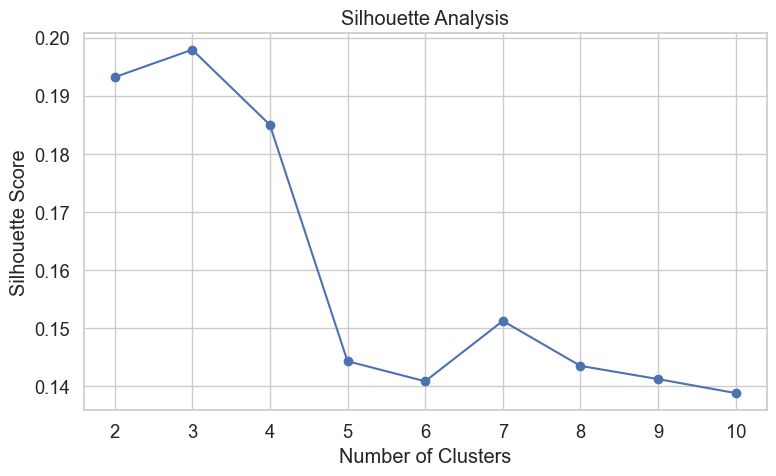

In [28]:

from sklearn.metrics import silhouette_score

# step 4a - determine number of clusters

silhouette_results = []

for k in cluster_range:

    model = KMeans(

        n_clusters=k,

        random_state=42,

        n_init=10

    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(

        X_scaled,

        labels

    )

    silhouette_results.append(score)

# step 4b - Create a table.

silhouette_df = pd.DataFrame({

    "Clusters": list(cluster_range),

    "Silhouette Score": silhouette_results

})

silhouette_df

# step 4c - Visualize.

fig, ax = plt.subplots(figsize=(8,5))

ax.plot(

    silhouette_df["Clusters"],

    silhouette_df["Silhouette Score"],

    marker="o"

)

ax.set_xlabel("Number of Clusters")

ax.set_ylabel("Silhouette Score")

ax.set_title("Silhouette Analysis")

plt.tight_layout()

plt.show()

### Insight:

The optimal number of clusters was selected by considering both:

- the Elbow Method
- the Silhouette Score

Using both methods reduces the likelihood of selecting too many or too few clusters.

### STEP 5 -  Train Final K-Means Model

- Based on the Elbow Method and Silhouette Score, the optimal number of clusters was selected.

- The final K-Means model is trained using the standardized behavioural features.

- Each rider is then assigned to one cluster representing a group of customers with similar historical behaviour.

In [29]:
optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_scaled)

segment_df["cluster"] = cluster_labels

segment_df.head()

# Check cluster sizes:

segment_df["cluster"].value_counts().sort_index()

cluster
0    1702
1    3297
2      22
3    4183
Name: count, dtype: int64

### STEP 6 - Cluster Profiling

- The average characteristics of each cluster are examined to understand how the discovered customer groups differ.

- This allows meaningful business interpretation of the clusters.

In [30]:
# step 6a - cluster profiling

cluster_profile = (
    segment_df
    .groupby("cluster")
    .agg(
        Riders=("user_id", "count"),
        Avg_Trips_30_days=("trips_last_30_days", "mean"),
        Avg_Trips_60_days=("trips_last_60_days", "mean"),
        Avg_Spend=("monetary_total", "mean"),
        Avg_Recency=("recency_days", "mean"),
        Avg_Account_Age=("account_age_days", "mean"),
        Churn_Rate=("churned", "mean")
    )
)

cluster_profile["Churn_Rate"] *= 100

cluster_profile.round(2)



,Riders,Avg_Trips_30_days,Avg_Trips_60_days,Avg_Spend,Avg_Recency,Avg_Account_Age,Churn_Rate
cluster,,,,,,,
0,1702,0.08,1.66,229.56,47.78,333.09,4.17
1,3297,1.69,2.99,203.26,11.74,337.08,3.64
2,22,2.14,4.27,288.25,14.23,1.41,0.00
3,4183,2.27,4.21,311.44,10.28,333.47,3.94


### Insight



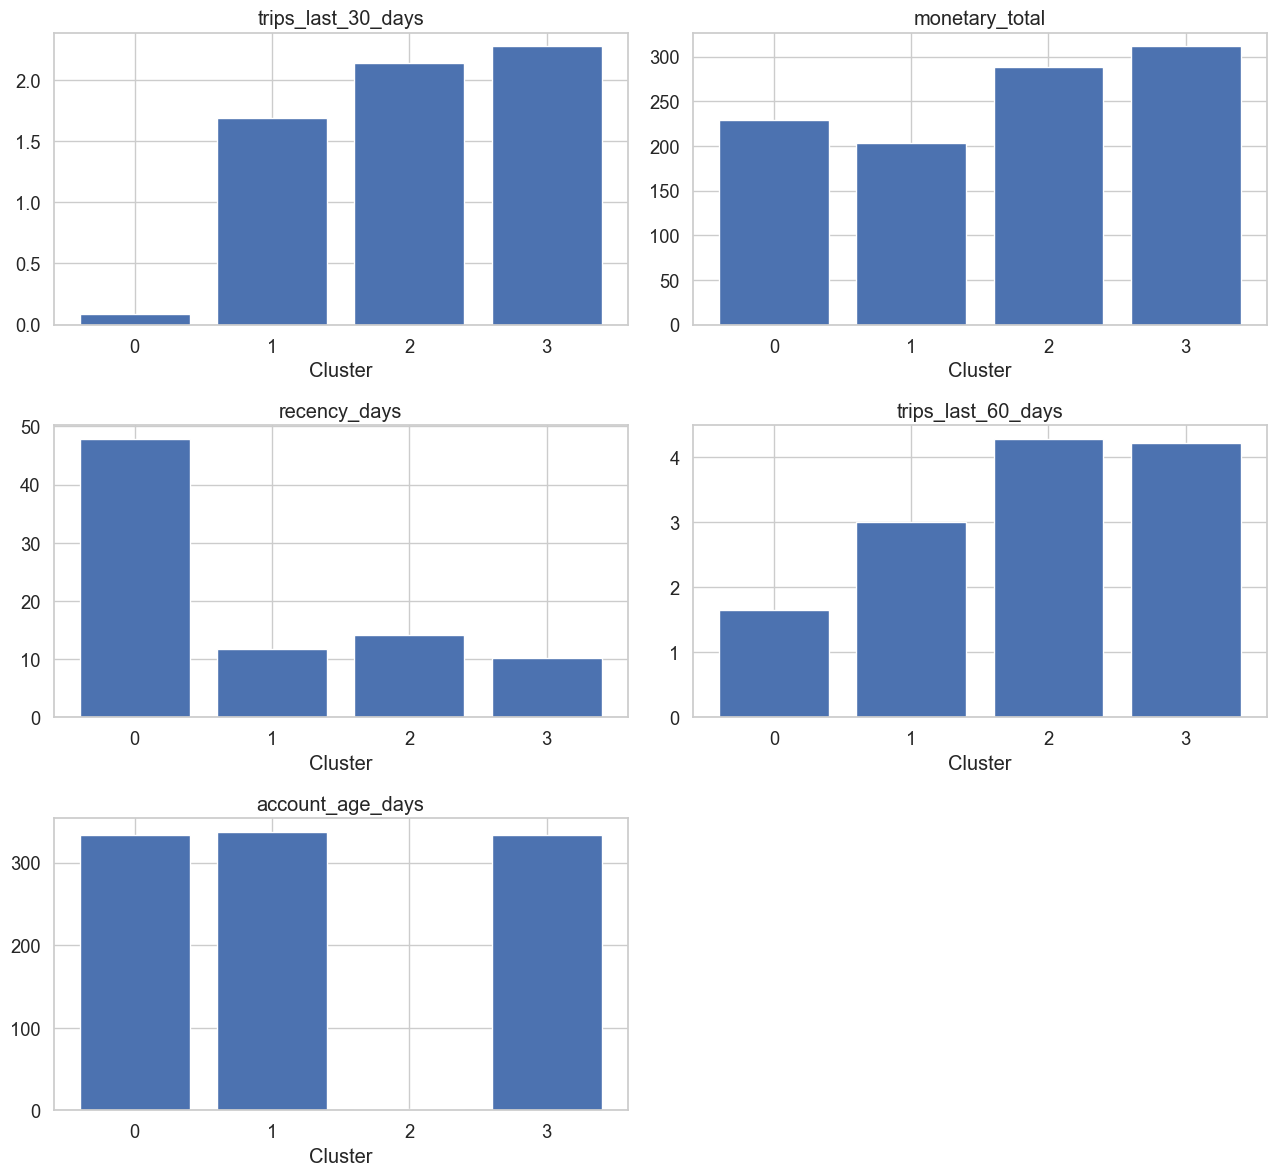

In [31]:
# step 6b - Visualize Cluster Characteristics
# Behavioural Comparison Across Clusters

# The average behavioural metrics are compared across the discovered customer clusters.

metrics = [
    "trips_last_30_days",
    "monetary_total",
    "recency_days",
    "trips_last_60_days",
    "account_age_days",
    "monetary_total"
]

fig, axes = plt.subplots(
    3,
    2,
    figsize=(13, 12)
)

axes = axes.flatten()

for ax, metric in zip(axes, metrics):

    data = (
        segment_df
        .groupby("cluster")[metric]
        .mean()
        .sort_index()
    )

    ax.bar(
        data.index.astype(str),
        data.values
    )

    ax.set_title(metric)
    ax.set_xlabel("Cluster")

# Hide unused subplot
axes[-1].set_visible(False)

plt.tight_layout()

plt.show()

### Insight

- The clusters differ substantially across multiple behavioural metrics, confirming that K-Means successfully identified groups with distinct riding patterns.

-  behavioural differences provide a useful basis for targeted marketing and customer engagement strategies.

### STEP 7 - Compare K-Means Clusters with Business Segments

The discovered K-Means clusters are compared with the existing business-defined segments.

This helps determine whether the data-driven clustering aligns with the original segmentation strategy.

In [32]:
# step 7a - comparison 
comparison = pd.crosstab(
    segment_df["cluster"],
    segment_df["segment"],
    margins=True
)

comparison

segment,At-Risk,Champions,Dormant,Loyal Riders,All
cluster,,,,,
0,728,534,326,114,1702
1,1697,782,616,202,3297
2,7,8,6,1,22
3,1091,2003,818,271,4183
All,3523,3327,1766,588,9204


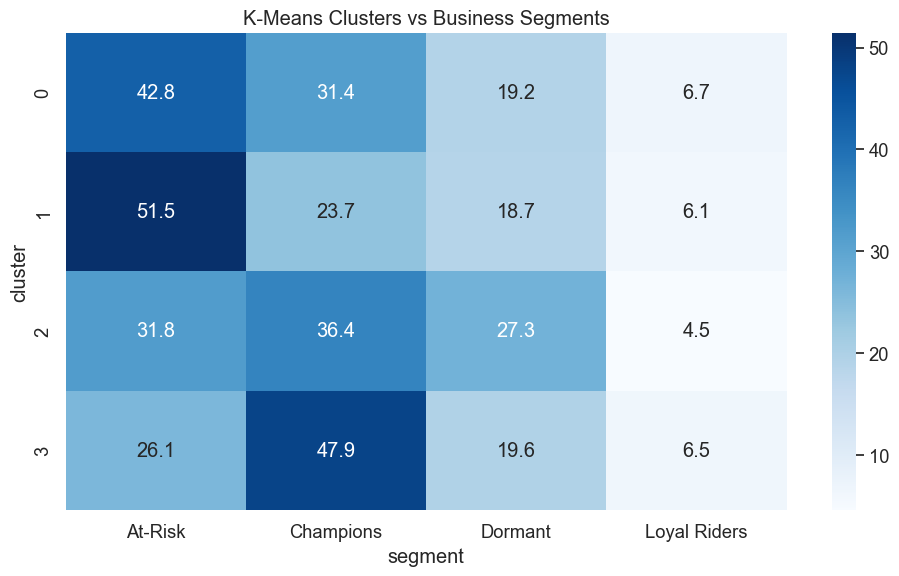

In [33]:
comparison_pct = pd.crosstab(
    segment_df["cluster"],
    segment_df["segment"],
    normalize="index"
) * 100

comparison_pct.round(1)

# step 7b - Visualize:

fig, ax = plt.subplots(figsize=(10,6))

sns.heatmap(
    comparison_pct,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    ax=ax
)

ax.set_title("K-Means Clusters vs Business Segments")

plt.tight_layout()

plt.show()

### Insight

The comparison shows the degree of agreement between the data-driven K-Means clusters and the predefined business segments.

Strong alignment suggests that the business segmentation captures meaningful behavioural patterns.

Differences indicate opportunities to refine the business segmentation using unsupervised learning.

In [34]:
# step 7c - Assign Business Names to Clusters

# K-Means produces numeric labels (0, 1, 2, 3), which are not meaningful on their own. Use the cluster profile from Step 9 to assign business-friendly names based on the observed characteristics, not by guessing.

# Start with a placeholder mapping:

cluster_name_map = {
    0: "Dormant Riders",
    1: "Regular Riders",
    2: "VIP Riders",
    3: "Champions"
}

segment_df["cluster_name"] = (
    segment_df["cluster"]
    .map(cluster_name_map)
)

segment_df[
    ["user_id", "cluster", "cluster_name"]
].head()

,user_id,cluster,cluster_name
0,R00000,3,Champions
1,R00001,0,Dormant Riders
2,R00002,3,Champions
3,R00004,1,Regular Riders
4,R00005,3,Champions


### Business Interpretation of K-Means Clusters

The K-Means algorithm identified four distinct behavioural customer groups.

- **Dormant Riders** have very low recent activity and the longest time since their last trip. These customers are suitable targets for reactivation campaigns.

- **Regular Riders** use the platform consistently but contribute moderate spending. Loyalty programmes and personalised offers may encourage increased usage.

- **VIP Riders** represent a very small group of exceptionally valuable customers with high spending, frequent trips and no observed churn during the study period.

- **Champions** are the largest high-value customer group, characterised by frequent trips, recent activity and the highest average spending. Retaining these riders should be a strategic priority for RideWise.

### Segment Overview

- The segmentation created during feature engineering assigns every rider to one behavioural group.

- These groups summarise rider engagement patterns and allow RideWise to develop targeted retention strategies.

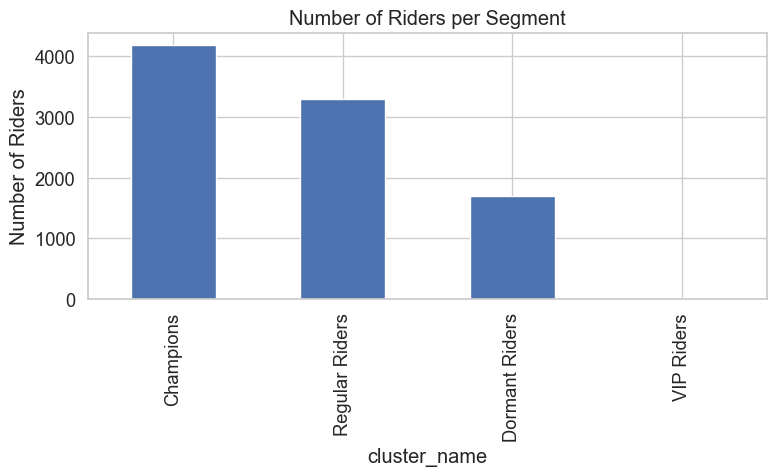

In [35]:

# step 7d - Segment Distribution
segment_counts = (
    segment_df["cluster_name"]
    .value_counts()
)

segment_counts

# Visualize.

fig, ax = plt.subplots(
    figsize=(8,5)
)

segment_counts.plot(
    kind="bar",
    ax=ax
)

ax.set_title("Number of Riders per Segment")
ax.set_ylabel("Number of Riders")

plt.tight_layout()
plt.show()




### insight:
- The customer base is distributed across four behavioural segments.

- Understanding the size of each segment helps RideWise prioritise retention resources and marketing investment.

- vip riders ia niche, high value-segment with only 22 riders

### step 8 - Churn Rate by Segment

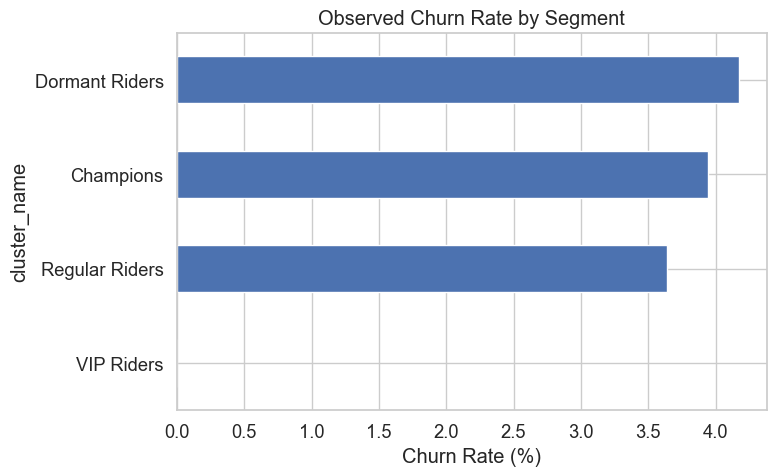

In [36]:
# step 8a - churn rate by segment
segment_summary = (
    segment_df
    .groupby("cluster_name")
    .agg(
        riders=("user_id","count"),
        churn_rate=("churned","mean")
    )
)

segment_summary["churn_rate"] *=100

segment_summary.round(2)

# Visualize.

fig, ax = plt.subplots(
    figsize=(8,5)
)

segment_summary["churn_rate"].sort_values().plot(
    kind="barh",
    ax=ax
)

ax.set_xlabel("Churn Rate (%)")
ax.set_title("Observed Churn Rate by Segment")

plt.tight_layout()
plt.show()

### STEP 9 - Business Insights

The K-Means algorithm identified four distinct customer groups with different behavioural characteristics.

Key observations:

- **Champions** form the largest customer segment, demonstrating the highest spending and the greatest trip frequency.
- **Regular Riders** use the platform consistently but contribute lower spending than Champions.
- **Dormant Riders** have the lowest recent activity and the longest time since their last trip, making them the primary target for reactivation campaigns.
- **VIP Riders** represent a very small niche of exceptionally valuable customers. Although they account for only a small proportion of riders, they exhibit very high activity and no observed churn during the study period.

In [37]:
# Recommendation Business Action

recommendations = pd.DataFrame({
    "Segment": [
        "Champions",
        "Regular Riders",
        "Dormant Riders",
        "VIP Riders"
    ],
    "Recommended Action": [
        "Reward loyalty through premium benefits and referral incentives.",
        "Increase engagement using personalised promotions and discounts.",
        "Launch reactivation campaigns and win-back offers.",
        "Provide exclusive rewards and personalised customer support."
    ]
})

recommendations

,Segment,Recommended Action
0,Champions,Reward loyalty through premium benefits and re...
1,Regular Riders,Increase engagement using personalised promoti...
2,Dormant Riders,Launch reactivation campaigns and win-back off...
3,VIP Riders,Provide exclusive rewards and personalised cus...


### Final Conclusion

- This notebook applied K-Means clustering to identify natural behavioural groups within the RideWise customer base.

- The Elbow Method and Silhouette Score were used to determine an appropriate number of clusters before training the final K-Means model.

- The resulting clusters revealed meaningful differences in customer behaviour, including spending patterns, trip frequency, recency and customer value.

- Comparison with the rule-based business segments showed partial agreement, indicating that both approaches provide useful but different perspectives on customer behaviour.

- Unlike the churn prediction model, which demonstrated limited predictive performance on this synthetic dataset, customer segmentation generated actionable business insights that can support marketing, customer retention and loyalty strategies.

- Overall, the segmentation analysis demonstrates how unsupervised machine learning can complement traditional business segmentation to improve customer understanding and decision-making.